# NOE (Liovillie space and Redfield)
## Author: Vineeth Francis Thalakottoor, vineeth.thalakottoor@cea.fr
- Nuclear Overhauser effect 
- In Liovillie Space
- Redfield Master equation
- Heteronuclear

In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib ipympl

# Import PyOR package
from PyORv2 import *

*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QunS                   (QuantumSystem from PyOR_QuantumSystem)
* QuantumSystems         (QuantumSystems from PyOR_QuantumSystem - for multiple systems)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting              (from PyOR_Plotting)
** Spro                  (from PyOR_SignalProcessing)
** constants             (from PyOR_PhysicalConstants)
** gamma                 (f

In [2]:
# Define the spin system
Spin_list = {"A" : "C13", "B" : "H1"}
QS = QunS(Spin_list,PrintDefault=False)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix


### Set parameters

In [3]:
QS.Configure(
    # Propagation Space
    PropagationSpace="Liouville",

    # Master Equation
    MasterEquation="Redfield",

    # Operator basis
    Basis_SpinOperators_Hilbert="Zeeman",

    # Field in TFalse
    B0=9.4,

    # Offset frequencies in Hz
    OFFSET={"A": 10.0, "B": 50.0},

    # J coupling
    Jcouplings=[("A", "B", 5.0)],

    # Define paris of spins coupled by dipolar interaction
    Dipole_Pairs = [("A","B")],

    # Initial and final spin temperature
    I_spintemp={"A": 300.0, "B": 300.0},
    F_spintemp={"A": 300.0, "B": 300.0},
    Lindblad_Temp = 300.0,

    # Relaxation Process
    Rprocess = "Auto-correlated Dipolar Heteronuclear",
    RelaxParDipole_tau = 10.0e-12,
    RelaxParDipole_bIS = [30.0e3],

    # Evolution parameters
    AcqDT = 0.0001,
    AcqAQ = 30.0,
    OdeMethod = 'DOP853',
    PropagationMethod = "Unitary Propagator",
    
    #Plotting
    PlotFigureSize = (10,5),
    PlotFontSize = 20,
)

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-632458696.0, -2514708003.2000003] from {'A': -632458696.0, 'B': -2514708003.2000003}
Offset    <- OFFSET    : [10.0, 50.0] from {'A': 10.0, 'B': 50.0}
Ispintemp <- I_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
Fspintemp <- F_spintemp: [300.0, 300.0] from {'A': 300.0, 'B': 300.0}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------
Larmor Frequency in MHz:  [-100.65893777 -400.22825914]
Larmor Frequency in MHz:  [-100.65893777 -400.22825914]
Larmor Frequency in MHz:  [-100.65893777 -400.22825914]


### Generate Hamiltonians

In [4]:
Hz = QS.Hamiltonian.Zeeman_RotFrame()

# J coupling Hamiltonian
Hj = QS.Hamiltonian.Jcoupling()

# Generating the commutation superoperator

#QLib = QuantumLibrary(QS)

Hz_L = QS.QuantumLibrary.CommutationSuperoperator(Hz+Hj)

### product operator basis (Shift Z or PMZ basis)

In [5]:
sort = 'negative to positive'
Index = False
Normal = True
Basis_PMZ, coh_PMZ, dic_PMZ = QS.Basis.ProductOperators_SpinHalf_PMZ(sort,Index,Normal)

### Initialize Density Matrix

In [6]:
Thermal_DensMatrix = True

if Thermal_DensMatrix:    
    # High Temperature
    HT_approx = True
    
    # Initial Density Matrix
    rho_in_L = QS.DensityMatrix.EquilibriumDensityMatrix(QS.Ispintemp,HT_approx)
    
    # Equlibrium Density Matrix
    rhoeq_L = QS.DensityMatrix.EquilibriumDensityMatrix(QS.Fspintemp,HT_approx)
else:
    rho_in = QS.Az + QS.Bz
    rhoeq = QS.Az + QS.Bz

Trace of density matrix =  1.0
Trace of density matrix =  1.0


In [7]:
rho_in_L.matrix

Matrix([
[0.250010016164232],
[                0],
[                0],
[                0],
[                0],
[0.249994009558359],
[                0],
[                0],
[                0],
[                0],
[0.250005990441641],
[                0],
[                0],
[                0],
[                0],
[0.249989983835768]])

In [8]:
rho_in_L.matrix

Matrix([
[0.250010016164232],
[                0],
[                0],
[                0],
[                0],
[0.249994009558359],
[                0],
[                0],
[                0],
[                0],
[0.250005990441641],
[                0],
[                0],
[                0],
[                0],
[0.249989983835768]])

In [9]:
QS.DensityMatrix.DensityMatrix_Components(rho_in_L,Basis_PMZ,dic_PMZ)

Density Matrix = 0.0 Iz1 Id2  + 2e-05 Id1 Iz2  + 0.5 Id1 Id2 


### Pulse

In [10]:
flip_angle1 = 0.0   # Flip angle Spin 1
flip_angle2 = 180.0 # Flip angle Spin 2

rho = QS.HardPulse.Rotate_Pulse(rho_in_L,flip_angle1,QS.Ay)
rho = QS.HardPulse.Rotate_Pulse(rho,flip_angle2,QS.By)

In [11]:
QS.DensityMatrix.DensityMatrix_Components(rho,Basis_PMZ,dic_PMZ)

Density Matrix = 0.0 Iz1 Id2  + -2e-05 Id1 Iz2  + 0.5 Id1 Id2 


## Evolution 

In [12]:
# Relaxation Superoperator
R_L = QS.RelaxationProcess.Relaxation()

start_time = time.time()
t, rho_t = QS.Evolutions.Evolution(rho,rhoeq_L,Hz_L,R_L)
end_time = time.time()
timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Total time = 1.6770026683807373 seconds 


### Expectation Value

In [13]:
det_Z1 = QS.Az_vec
det_Z2 = QS.Bz_vec

t, signal_Z1 = QS.Evolutions.Expectation(rho_t,det_Z1)
t, signal_Z2 = QS.Evolutions.Expectation(rho_t,det_Z2)

In [14]:
MoA = rho_in_L.Expectation(QS.Az_vec)
MoB = rho_in_L.Expectation(QS.Bz_vec)

## Plotting

/home/vineeth/venvs/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/vineeth/venvs/pyorv2/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


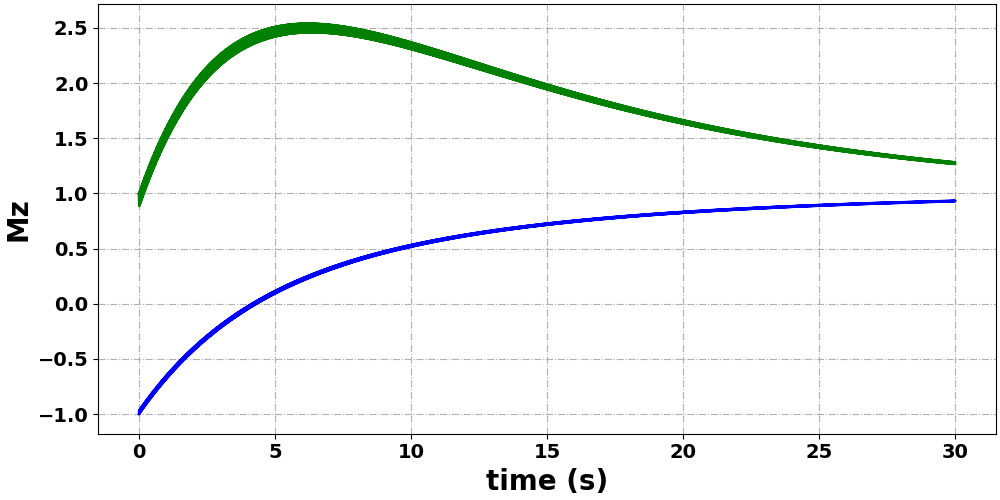

In [15]:
QS.Plotting.PlottingMulti([t,t],[signal_Z1/MoA,signal_Z2/MoB],"time (s)","Mz",["green","blue"])